# LeetCode #393: UTF-8 Validation

https://leetcode.com/problems/utf-8-validation/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (convert to binary strings)** | $O(n)$ | $O(n)$ |
| **Bit-Masking In-Place** ★ | $O(n)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force (convert to binary strings)
Convert each integer to its 8-bit binary string, then parse the leading bits with string slicing. Correct but allocates $O(n)$ strings unnecessarily.

### Optimal: Bit-Masking In-Place ★
Use bitmasks directly on the integers. A leading byte's top bits determine how many continuation bytes (`10xxxxxx`) follow. Check each byte with `& 0x80` and `& 0xC0` masks without any string conversion, running in $O(n)$ time and $O(1)$ space.

**Why this is better than Brute Force:** Avoids string allocation and parsing overhead — pure integer bit operations are cache-friendly and allocation-free.

**Constraints:**
* `1 <= data.length <= 2 * 10^4`
* `0 <= data[i] <= 255`

## Solutions

### C#

In [ ]:
public bool ValidUtf8(int[] data) {
    int continuationBytesNeeded = 0;
    foreach (int b in data) {
        if (continuationBytesNeeded > 0) {
            // Each continuation byte must match 10xxxxxx pattern
            if ((b & 0xC0) != 0x80) return false;
            continuationBytesNeeded--;
        } else {
            // Determine how many bytes this codepoint uses from leading bits
            if ((b & 0x80) == 0)          continuationBytesNeeded = 0; // 0xxxxxxx (1-byte)
            else if ((b & 0xE0) == 0xC0)  continuationBytesNeeded = 1; // 110xxxxx (2-byte)
            else if ((b & 0xF0) == 0xE0)  continuationBytesNeeded = 2; // 1110xxxx (3-byte)
            else if ((b & 0xF8) == 0xF0)  continuationBytesNeeded = 3; // 11110xxx (4-byte)
            else return false; // Invalid leading byte pattern
        }
    }
    // All expected continuation bytes must have been consumed
    return continuationBytesNeeded == 0;
}

### Python

In [ ]:
def validUtf8(self, data: list[int]) -> bool:
    continuations_needed = 0
    for b in data:
        if continuations_needed > 0:
            # Continuation bytes must match the 10xxxxxx pattern
            if b & 0xC0 != 0x80:
                return False
            continuations_needed -= 1
        else:
            # Decode the number of bytes in this UTF-8 character from leading bits
            if   b & 0x80 == 0:    continuations_needed = 0
            elif b & 0xE0 == 0xC0: continuations_needed = 1
            elif b & 0xF0 == 0xE0: continuations_needed = 2
            elif b & 0xF8 == 0xF0: continuations_needed = 3
            else: return False
    # No pending continuation bytes means a well-formed sequence
    return continuations_needed == 0

### Go

In [ ]:
func validUtf8(data []int) bool {
    continuationsNeeded := 0
    for _, b := range data {
        if continuationsNeeded > 0 {
            // Validate continuation byte starts with 10xxxxxx
            if b&0xC0 != 0x80 {
                return false
            }
            continuationsNeeded--
        } else {
            // Leading bits determine the codepoint's byte length
            switch {
            case b&0x80 == 0:    continuationsNeeded = 0
            case b&0xE0 == 0xC0: continuationsNeeded = 1
            case b&0xF0 == 0xE0: continuationsNeeded = 2
            case b&0xF8 == 0xF0: continuationsNeeded = 3
            default:             return false
            }
        }
    }
    return continuationsNeeded == 0
}

### Rust

In [ ]:
pub fn valid_utf8(data: Vec<i32>) -> bool {
    let mut continuations_needed = 0u32;
    for b in data {
        if continuations_needed > 0 {
            // Continuation bytes must match the 10xxxxxx mask
            if b & 0xC0 != 0x80 {
                return false;
            }
            continuations_needed -= 1;
        } else {
            // Inspect leading bits to classify the starting byte
            continuations_needed = match b {
                b if b & 0x80 == 0    => 0,
                b if b & 0xE0 == 0xC0 => 1,
                b if b & 0xF0 == 0xE0 => 2,
                b if b & 0xF8 == 0xF0 => 3,
                _ => return false,
            };
        }
    }
    continuations_needed == 0
}

## Example Scenarios

**1. Common Case**
**Input:** data = [197, 130, 1] → bytes: 11000101, 10000010, 00000001
11000101 matches 110xxxxx → 1 continuation needed. 10000010 matches 10xxxxxx → satisfied. 00000001 is a valid 1-byte char. Result: **true**.

**2. Slightly Complex**
**Input:** data = [235, 140, 4] → bytes: 11101011, 10001100, 00000100
11101011 matches 1110xxxx → 2 continuations needed. 10001100 satisfies the first. 00000100 starts with 0 (ASCII byte), but we still need 1 continuation. Result: **false**.

**3. Edge Case: Time Factor**
**Input:** 20,000 valid ASCII bytes (all ≤ 127, bit 7 = 0)
Every byte hits the `0xxxxxxx` branch: zero continuations needed, instant classification. $O(n)$ with minimal branching — fastest path through the validator.

**4. Edge Case: Space Factor**
**Input:** data = [240, 162, 138, 147] → 4-byte UTF-8 codepoint (emoji-class)
11110000 → 3 continuations needed; three 10xxxxxx bytes follow. Space is $O(1)$ regardless; only one counter is maintained throughout the scan.

**5. Almost-Impossible but Plausible**
**Input:** data = [11111111] → byte 0xFF (11111111)
Leading bits 11111111 match none of the valid patterns (11110xxx is the maximum). Returns **false**. Technically a valid integer input but an invalid UTF-8 leader byte — an easy trap for implementations using string conversion.

### Infographic

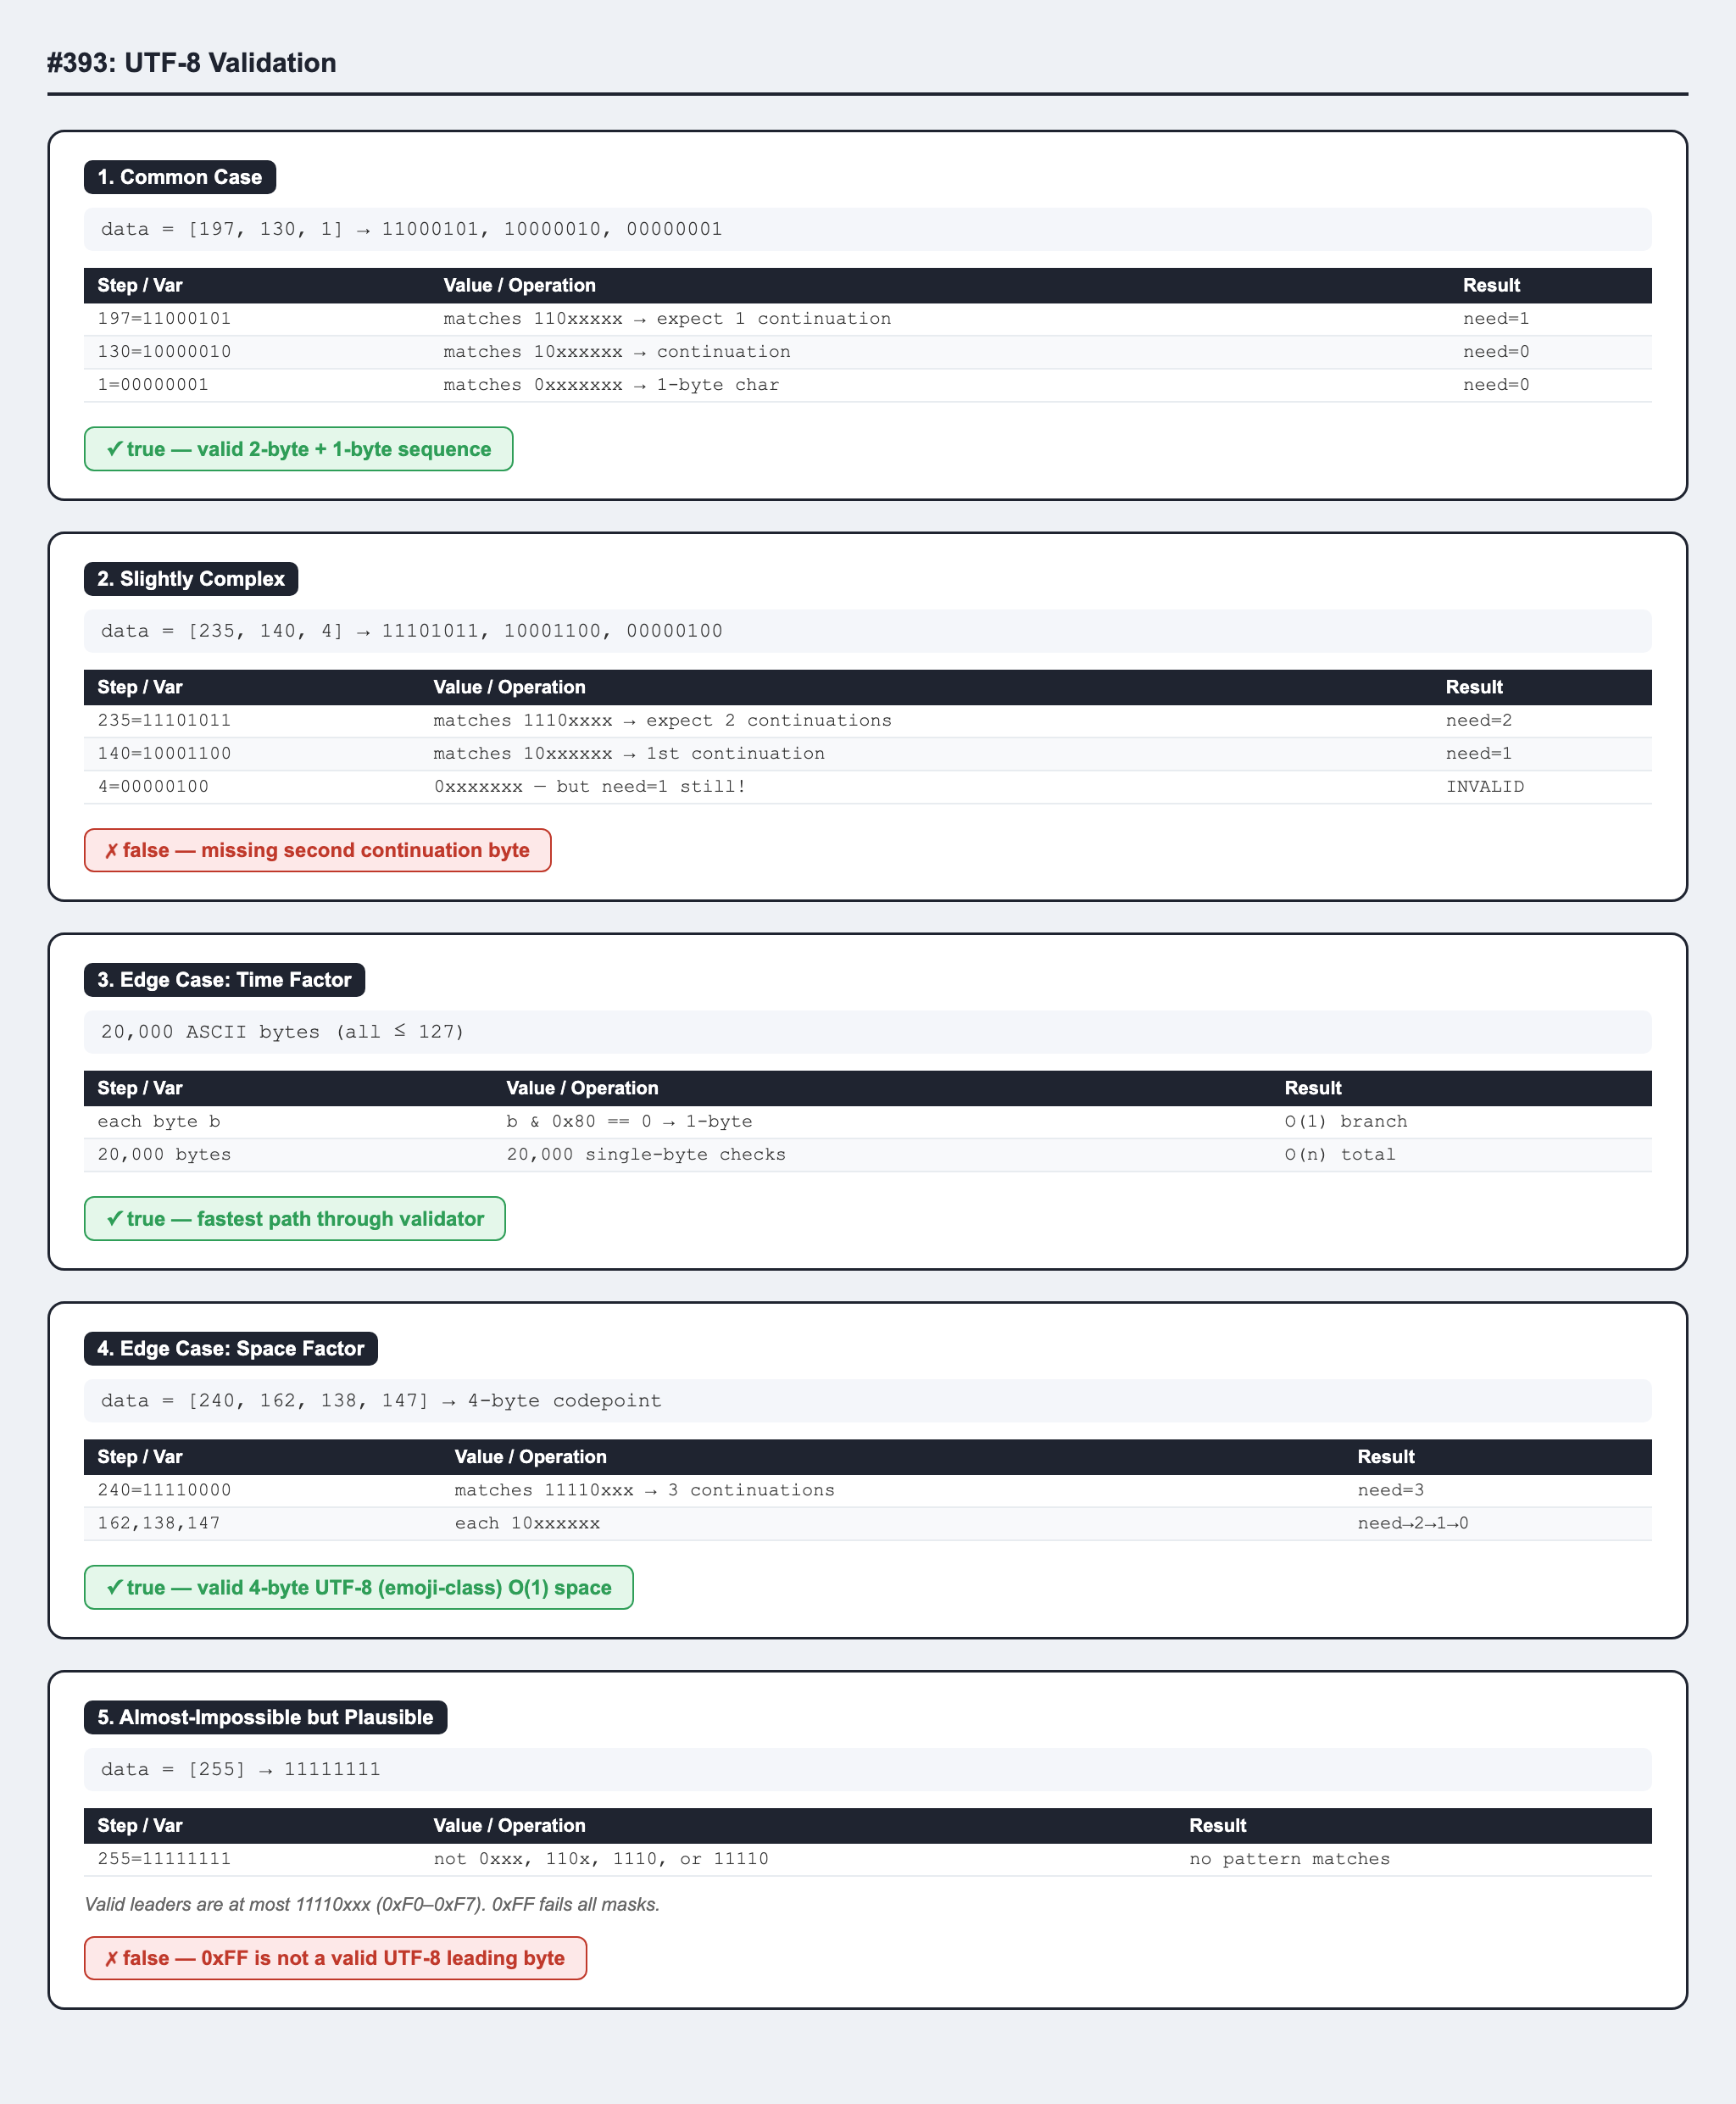